# Solución: Clasificación con Naive Bayes: diagnóstico de tumores de mama

**Objetivo:** construir un clasificador Gaussian Naive Bayes que prediga si un tumor es **maligno** o **benigno** a partir de mediciones de sus células, y evaluarlo con accuracy, reporte de clasificación y matriz de confusión.

**Dataset:** *Breast Cancer Wisconsin* (incluido en scikit-learn): 569 tumores, 30 variables numéricas y una clase binaria.

## 1. Librerías

Usamos `pandas` para explorar, `matplotlib` para graficar y `scikit-learn` para el modelo y las métricas. La función `hallazgo()` imprime conclusiones calculadas a partir de los datos, de modo que se actualizan solas si los datos cambian.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

RANDOM_STATE = 42

def hallazgo(texto):
    print(f"🔎 Hallazgo: {texto}")

## 2. Carga de datos

Convertimos los datos a un `DataFrame` para explorarlos con nombres de columna. En este dataset la clase viene codificada como **0 = maligno** y **1 = benigno**.

In [2]:
datos = load_breast_cancer(as_frame=True)
df = datos.frame.copy()
df["diagnostico"] = df["target"].map({0: "maligno", 1: "benigno"})

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


## 3. EDA mínimo necesario

Solo revisamos lo que influye en las decisiones del modelo:

1. **Valores nulos**: Naive Bayes de scikit-learn no acepta datos faltantes.
2. **Balance de clases**: define si debemos estratificar la partición y si basta con mirar el accuracy.
3. **Forma de las distribuciones por clase**: GaussianNB supone que cada variable sigue una distribución normal dentro de cada clase.
4. **Correlación entre variables**: Naive Bayes supone que las variables son independientes dentro de cada clase.

### 3.1 Valores nulos

In [3]:
nulos = df.isna().sum().sum()
hallazgo(f"el dataset tiene {nulos} valores nulos" + (": no se requiere imputación." if nulos == 0 else ": hay que imputar antes de entrenar."))

🔎 Hallazgo: el dataset tiene 0 valores nulos: no se requiere imputación.


### 3.2 Balance de clases

             casos  proporción
diagnostico                   
benigno        357       0.627
maligno        212       0.373


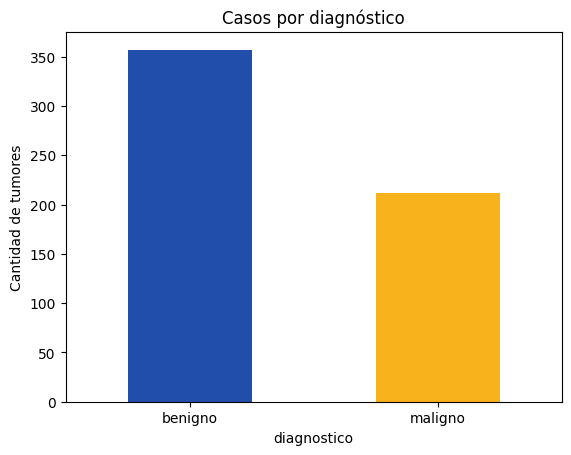

🔎 Hallazgo: la clase 'maligno' representa el 37.3% de los casos: las clases están desbalanceadas, así que estratificaremos la partición y no nos quedaremos solo con el accuracy.


In [4]:
conteo = df["diagnostico"].value_counts()
proporcion = df["diagnostico"].value_counts(normalize=True)
print(pd.DataFrame({"casos": conteo, "proporción": proporcion.round(3)}))

conteo.plot(kind="bar", color=["#214DAB", "#F8B31C"], rot=0, title="Casos por diagnóstico")
plt.ylabel("Cantidad de tumores")
plt.show()

minoritaria = proporcion.idxmin()
desbalance = proporcion.min() < 0.45
hallazgo(f"la clase '{minoritaria}' representa el {proporcion.min():.1%} de los casos: "
         + ("las clases están desbalanceadas, así que estratificaremos la partición y "
            "no nos quedaremos solo con el accuracy." if desbalance else "las clases están equilibradas."))

### 3.3 Distribución de algunas variables por clase

Revisamos tres variables representativas. Si las dos clases muestran distribuciones distintas, la variable ayuda a separarlas. La forma aproximadamente de campana dentro de cada clase es lo que asume GaussianNB.

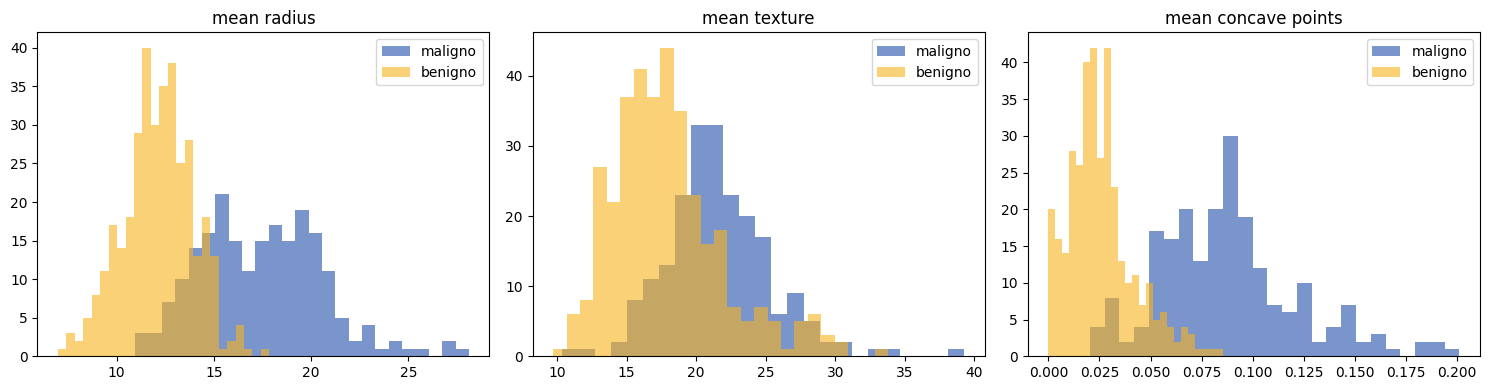

             mean radius  mean texture  mean concave points
diagnostico                                                
benigno           12.147        17.915                0.026
maligno           17.463        21.605                0.088
🔎 Hallazgo: 'mean radius' es en promedio mayor en tumores malignos (17.463 vs 12.147).
🔎 Hallazgo: 'mean texture' es en promedio mayor en tumores malignos (21.605 vs 17.915).
🔎 Hallazgo: 'mean concave points' es en promedio mayor en tumores malignos (0.088 vs 0.026).


In [5]:
variables = ["mean radius", "mean texture", "mean concave points"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    for clase, color in [("maligno", "#214DAB"), ("benigno", "#F8B31C")]:
        ax.hist(df.loc[df["diagnostico"] == clase, var], bins=25, alpha=0.6, label=clase, color=color)
    ax.set_title(var)
    ax.legend()
plt.tight_layout()
plt.show()

medias = df.groupby("diagnostico")[variables].mean().round(3)
print(medias)
for var in variables:
    mayor = medias[var].idxmax()
    hallazgo(f"'{var}' es en promedio mayor en tumores {mayor}s "
             f"({medias.loc['maligno', var]} vs {medias.loc['benigno', var]}).")

### 3.4 Correlación entre variables

El modelo es *naive* porque asume que las variables no se relacionan entre sí dentro de cada clase. Medimos cuánto se aleja este dataset de ese supuesto con tres variables de tamaño del tumor.

In [6]:
tamano = ["mean radius", "mean perimeter", "mean area"]
corr = df[tamano].corr().round(3)
print(corr)

corr_min = corr.where(~np.eye(len(tamano), dtype=bool)).min().min()
hallazgo(f"radio, perímetro y área tienen correlaciones de al menos {corr_min}: "
         "el supuesto de independencia NO se cumple. Igual entrenaremos el modelo "
         "para comprobar si clasifica bien a pesar de ello.")

                mean radius  mean perimeter  mean area
mean radius           1.000           0.998      0.987
mean perimeter        0.998           1.000      0.987
mean area             0.987           0.987      1.000
🔎 Hallazgo: radio, perímetro y área tienen correlaciones de al menos 0.987: el supuesto de independencia NO se cumple. Igual entrenaremos el modelo para comprobar si clasifica bien a pesar de ello.


## 4. Partición entrenamiento / prueba

Separamos 80% para entrenar y 20% para evaluar. Usamos `stratify=y` porque el EDA mostró clases desbalanceadas: así ambas particiones conservan la misma proporción de malignos y benignos.

No escalamos las variables: GaussianNB estima una media y una varianza por variable y por clase, por lo que las diferencias de escala no afectan al modelo.

In [7]:
X = df[datos.feature_names]
y = df["diagnostico"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("Proporción de malignos  -> train: {:.3f} | test: {:.3f}".format(
    (y_train == "maligno").mean(), (y_test == "maligno").mean()))

Entrenamiento: (455, 30) | Prueba: (114, 30)
Proporción de malignos  -> train: 0.374 | test: 0.368


## 5. Entrenamiento del modelo

Al entrenar, GaussianNB calcula:

- **P(clase)**: la proporción de cada clase en entrenamiento.
- La **media y la varianza** de cada variable dentro de cada clase, que usa para estimar P(variable | clase).

In [8]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)

priors = pd.Series(modelo.class_prior_, index=modelo.classes_).round(3)
print("Probabilidades a priori P(clase):")
print(priors)

Probabilidades a priori P(clase):
benigno    0.626
maligno    0.374
dtype: float64


## 6. Predicción

`predict` entrega la clase con mayor probabilidad a posteriori; `predict_proba` entrega esa probabilidad para cada clase. Revisamos un caso de prueba como ejemplo.

In [9]:
y_pred = modelo.predict(X_test)

caso = X_test.iloc[[0]]
proba = pd.Series(modelo.predict_proba(caso)[0], index=modelo.classes_).round(4)
print("Probabilidad a posteriori del primer caso de prueba:")
print(proba)
hallazgo(f"el modelo predice '{proba.idxmax()}' con {proba.max():.1%} de probabilidad; "
         f"el diagnóstico real es '{y_test.iloc[0]}'."
         + (" Naive Bayes suele entregar probabilidades extremas, cercanas a 0 o 1." if proba.max() > 0.99 else ""))

Probabilidad a posteriori del primer caso de prueba:
benigno    1.0
maligno    0.0
dtype: float64
🔎 Hallazgo: el modelo predice 'benigno' con 100.0% de probabilidad; el diagnóstico real es 'benigno'. Naive Bayes suele entregar probabilidades extremas, cercanas a 0 o 1.


## 7. Evaluación

### 7.1 Accuracy
Proporción de casos clasificados correctamente. Lo comparamos con un clasificador trivial que siempre predice la clase mayoritaria: el modelo solo aporta valor si lo supera.

In [10]:
acc = accuracy_score(y_test, y_pred)
acc_trivial = (y_test == y_train.mode()[0]).mean()

print(f"Accuracy Naive Bayes:      {acc:.4f}")
print(f"Accuracy clase mayoritaria: {acc_trivial:.4f}")
hallazgo(f"el modelo supera al clasificador trivial por {(acc - acc_trivial) * 100:.1f} puntos porcentuales.")

Accuracy Naive Bayes:      0.9386
Accuracy clase mayoritaria: 0.6316
🔎 Hallazgo: el modelo supera al clasificador trivial por 30.7 puntos porcentuales.


### 7.2 Reporte de clasificación
Con clases desbalanceadas necesitamos métricas por clase:

- **Precision**: de los casos que el modelo marcó como una clase, cuántos lo eran realmente.
- **Recall**: de los casos reales de una clase, cuántos detectó el modelo.
- **F1-score**: equilibrio entre precision y recall.

En diagnóstico médico, el **recall de la clase maligno** es la métrica crítica: un maligno no detectado es el error más costoso.

In [11]:
print(classification_report(y_test, y_pred, digits=3))

reporte = classification_report(y_test, y_pred, output_dict=True)
n_pred_mal = (y_pred == "maligno").sum()
n_real_mal = (y_test == "maligno").sum()
n_pred_ben = (y_pred == "benigno").sum()
n_real_ben = (y_test == "benigno").sum()

hallazgo(f"precision de 'maligno' = {reporte['maligno']['precision']:.3f}: de los {n_pred_mal} tumores que el modelo "
         f"marcó como malignos, {reporte['maligno']['precision']:.1%} realmente lo eran.")
hallazgo(f"recall de 'maligno' = {reporte['maligno']['recall']:.3f}: de los {n_real_mal} tumores malignos reales, "
         f"el modelo detectó el {reporte['maligno']['recall']:.1%}; el resto pasó como benigno.")
hallazgo(f"precision de 'benigno' = {reporte['benigno']['precision']:.3f}: de los {n_pred_ben} tumores que el modelo "
         f"declaró benignos, {reporte['benigno']['precision']:.1%} realmente lo eran.")
hallazgo(f"recall de 'benigno' = {reporte['benigno']['recall']:.3f}: de los {n_real_ben} tumores benignos reales, "
         f"el modelo reconoció el {reporte['benigno']['recall']:.1%}.")

              precision    recall  f1-score   support

     benigno      0.911     1.000     0.954        72
     maligno      1.000     0.833     0.909        42

    accuracy                          0.939       114
   macro avg      0.956     0.917     0.931       114
weighted avg      0.944     0.939     0.937       114

🔎 Hallazgo: precision de 'maligno' = 1.000: de los 35 tumores que el modelo marcó como malignos, 100.0% realmente lo eran.
🔎 Hallazgo: recall de 'maligno' = 0.833: de los 42 tumores malignos reales, el modelo detectó el 83.3%; el resto pasó como benigno.
🔎 Hallazgo: precision de 'benigno' = 0.911: de los 79 tumores que el modelo declaró benignos, 91.1% realmente lo eran.
🔎 Hallazgo: recall de 'benigno' = 1.000: de los 72 tumores benignos reales, el modelo reconoció el 100.0%.


**¿Qué significan precision y recall en este problema?**

- **Precision de maligno** responde: *cuando el modelo dice "maligno", ¿cuánto podemos confiar?* Una precision baja implicaría alarmar a pacientes sanos y someterlos a exámenes innecesarios (falsos positivos).
- **Recall de maligno** responde: *de todos los cánceres reales, ¿cuántos detecta el modelo?* Un recall bajo significa cánceres que pasan como benignos (falsos negativos): el paciente no recibe tratamiento a tiempo.
- **Precision de benigno** responde: *cuando el modelo dice "benigno", ¿cuánto podemos confiar?* Si no es perfecta, entre los casos declarados benignos se esconden malignos: son los mismos falsos negativos vistos desde la otra clase.
- **Recall de benigno** responde: *de los tumores benignos reales, ¿cuántos reconoce como tales?*

En este modelo la precision de maligno es alta pero el recall de maligno es la métrica más débil: el modelo es **conservador** para declarar un tumor maligno. Rara vez se equivoca cuando lo hace, pero deja pasar algunos cánceres. En un contexto médico conviene priorizar el **recall de maligno**, aunque eso implique aceptar más falsos positivos.

### 7.3 Matriz de confusión
Muestra en qué se equivoca el modelo. Ordenamos las etiquetas con **maligno** primero para leer directamente los malignos no detectados (falsos negativos).

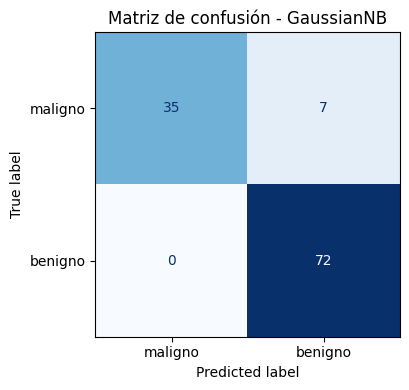

🔎 Hallazgo: 7 tumores malignos fueron clasificados como benignos (falsos negativos) y 0 benignos como malignos (falsos positivos).


In [12]:
etiquetas = ["maligno", "benigno"]

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=etiquetas, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión - GaussianNB")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred, labels=etiquetas)
fn, fp = cm[0, 1], cm[1, 0]
hallazgo(f"{fn} tumores malignos fueron clasificados como benignos (falsos negativos) y "
         f"{fp} benignos como malignos (falsos positivos).")

## 8. Conclusiones

- Aunque radio, perímetro y área están fuertemente correlacionados (el supuesto *naive* no se cumple), GaussianNB logra un accuracy alto y supera claramente al clasificador trivial.
- El desbalance de clases justificó estratificar la partición y revisar métricas por clase, no solo el accuracy.
- El error más relevante es el de los malignos clasificados como benignos: es el número a vigilar si el modelo se usara como apoyo al diagnóstico.